In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import cv2

In [3]:
import cv2
import numpy as np

def get_random_sample(img_size=200, rect_size=40):
    img = np.zeros((img_size, img_size), dtype=np.float32)

    # Top-left corner
    x1 = np.random.randint(0, img_size - rect_size)
    y1 = np.random.randint(0, img_size - rect_size)

    # Bottom-right corner
    x2 = x1 + rect_size
    y2 = y1 + rect_size

    # Draw rectangle
    img[y1:y2, x1:x2] = 1.0

    # Return image and ALL 4 coordinates
    return img, x1, y1, x2, y2

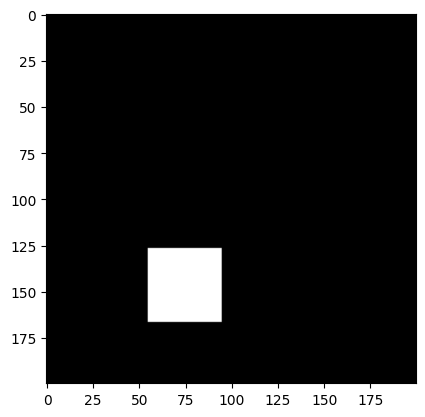

In [4]:
plt.imshow(get_random_sample()[0],cmap='gray')

In [5]:
import torch
from torch.utils.data import Dataset,DataLoader

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class SimpleKeypointDataset(Dataset):
    def __init__(self, length=1000, img_size=200):
        self.length = length
        self.img_size = img_size

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Get 4 coords
        img, x1, y1, x2, y2 = get_random_sample(self.img_size)

        # Normalize ALL of them to [0, 1]
        target = torch.tensor([
            x1 / self.img_size,
            y1 / self.img_size,
            x2 / self.img_size,
            y2 / self.img_size
        ], dtype=torch.float32)

        img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)

        return img_tensor, target

In [7]:
# Sample Check
data = SimpleKeypointDataset()

dataset = DataLoader(data, batch_size=10, shuffle=True)

In [8]:
images,targets = next(iter(dataset))

images.shape,targets.shape

(torch.Size([10, 1, 200, 200]), torch.Size([10, 4]))

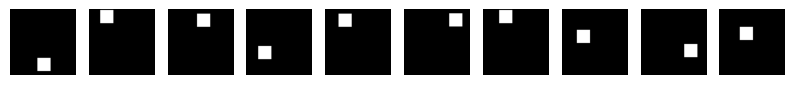

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i, image in enumerate(images):
    plt.subplot(1, images.shape[0], i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

In [10]:
import torch.nn as nn

class KeypointCNN(nn.Module):
    def __init__(self):
        super(KeypointCNN, self).__init__()

        # 1. Feature Extractor (Conv layers)
        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # 2. Regressor (Linear layers)
        # Input size calculation: 64 channels * 25 width * 25 height
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 25 * 25, 128),
            nn.ReLU(),
            nn.Linear(128, 4), # Output is x, y
            nn.Sigmoid()       # Forces output between 0 and 1
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [11]:
import torch.optim as optim

# 1. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KeypointCNN().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

dataloader = DataLoader(SimpleKeypointDataset(length=1000),
                        batch_size=8,
                        shuffle=True,
                        num_workers=16)

# 2. Training Loop
num_epochs = 15 # Since data is simple, 10 epochs should be enough

print("Starting Training...")

for epoch in range(num_epochs):
    running_loss = 0.0

    for images, targets in dataloader:
        # Move data to device
        images = images.to(device)
        targets = targets.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, targets)

        # Backward pass & Optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Print average loss per epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(dataloader):.6f}")

print("Training Complete!")

Starting Training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch [1/15], Loss: 0.005164
Epoch [2/15], Loss: 0.000170
Epoch [3/15], Loss: 0.000098
Epoch [4/15], Loss: 0.000074
Epoch [5/15], Loss: 0.000095
Epoch [6/15], Loss: 0.000129
Epoch [7/15], Loss: 0.000062
Epoch [8/15], Loss: 0.000097
Epoch [9/15], Loss: 0.000095
Epoch [10/15], Loss: 0.000044
Epoch [11/15], Loss: 0.000035
Epoch [12/15], Loss: 0.000038
Epoch [13/15], Loss: 0.000035
Epoch [14/15], Loss: 0.000046
Epoch [15/15], Loss: 0.000052
Training Complete!


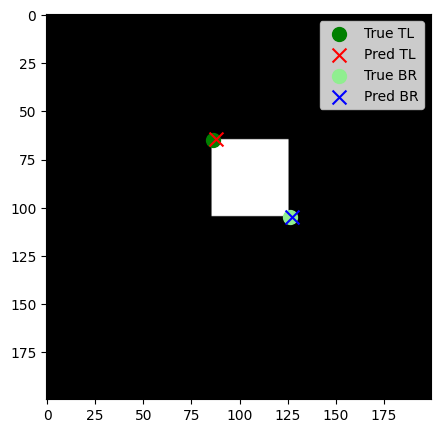

In [13]:
import matplotlib.pyplot as plt
img_size = 200

def predict_and_plot(model, dataset):
    # 1. Switch model to evaluation mode
    model.eval()

    # 2. Get a random sample from the dataset
    # (We take the first item here, but you can pick any index)
    img_tensor, target = dataset[np.random.randint(0, len(dataset))]

    # 3. Add batch dimension: (1, 200, 200) -> (1, 1, 200, 200)
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # 4. Forward pass (No grad needed for inference)
    with torch.no_grad():
        prediction = model(input_tensor)

    # 5. Extract data for plotting
    # Move back to CPU and convert to numpy
    pred_coords = prediction.cpu().numpy()[0]
    true_coords = target.numpy()
    img_plot = img_tensor[0].numpy()

    # 6. Un-normalize coordinates
    # pred_coords is now an array of 4 items
    x1_p, y1_p, x2_p, y2_p = pred_coords * img_size
    x1_t, y1_t, x2_t, y2_t = true_coords * img_size

    # 7. Plotting
    plt.figure(figsize=(5, 5))
    plt.imshow(img_plot, cmap='gray')

    # Plot Top-Left (Red)
    plt.scatter([x1_t], [y1_t], c='green', s=100, label='True TL')
    plt.scatter([x1_p], [y1_p], c='red', s=100, marker='x', label='Pred TL')

    # Plot Bottom-Right (Blue)
    plt.scatter([x2_t], [y2_t], c='lightgreen', s=100, label='True BR')
    plt.scatter([x2_p], [y2_p], c='blue', s=100, marker='x', label='Pred BR')

    plt.legend()
    plt.show()

# Run the function
predict_and_plot(model, dataloader.dataset)